In [6]:
# Student Exam Score Dataset 
import pandas as pd
import numpy
df = pd.read_csv("01_student_exam_scores.csv")
df.head()

,student_id,study_hours,attendance_pct,prev_score,final_score,passed
0,1,4.7,72.4,57.8,75.6,1
1,2,4.7,52.5,66.7,66.7,1
2,3,4.6,76.7,64.7,80.1,1
3,4,6.3,76.7,45.2,72.2,1
4,5,5.5,94.7,60.8,82.0,1


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      800 non-null    int64  
 1   study_hours     800 non-null    float64
 2   attendance_pct  800 non-null    float64
 3   prev_score      800 non-null    float64
 4   final_score     800 non-null    float64
 5   passed          800 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 37.6 KB


,student_id,study_hours,attendance_pct,prev_score,final_score,passed
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,4.991250,74.405250,59.694500,74.325375,0.990000
std,231.0844,1.961085,14.368834,19.822663,10.995485,0.099561
min,1.0000,0.000000,15.900000,0.000000,36.100000,0.000000
25%,200.7500,3.600000,64.775000,46.175000,66.900000,1.000000
50%,400.5000,5.000000,74.950000,60.250000,74.050000,1.000000
75%,600.2500,6.200000,85.100000,73.225000,81.900000,1.000000
max,800.0000,12.000000,100.000000,100.000000,100.000000,1.000000


In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [10]:
df['passed'].value_counts()

passed
1    792
0      8
Name: count, dtype: int64

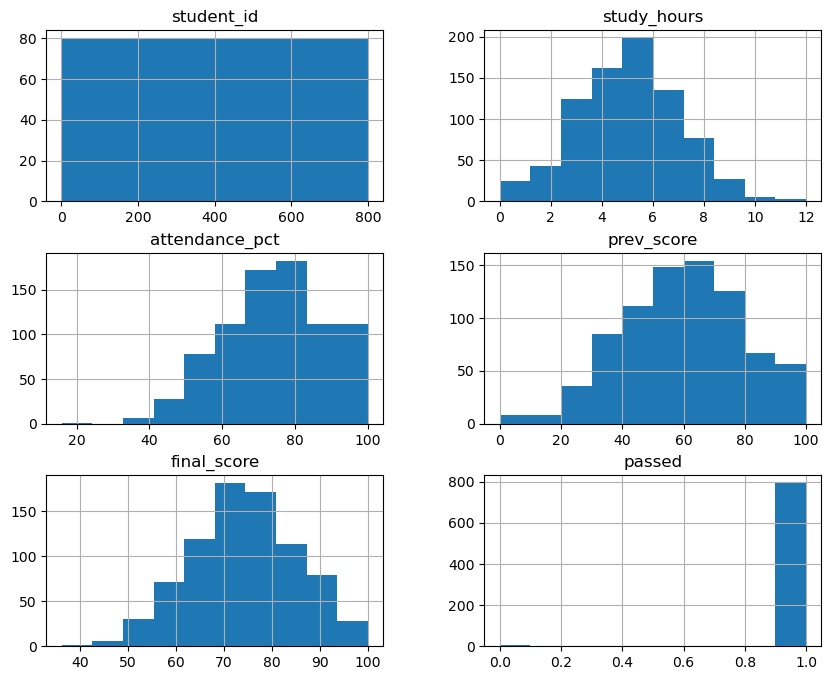

In [11]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

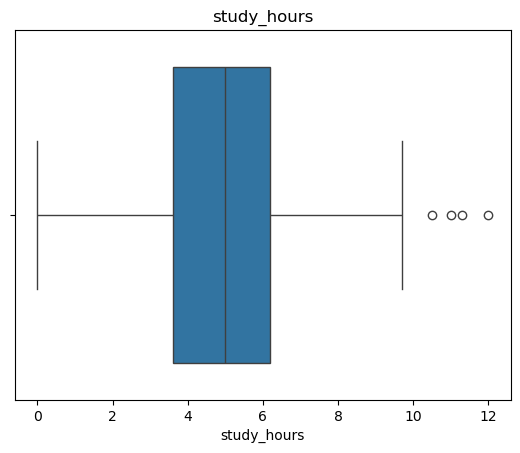

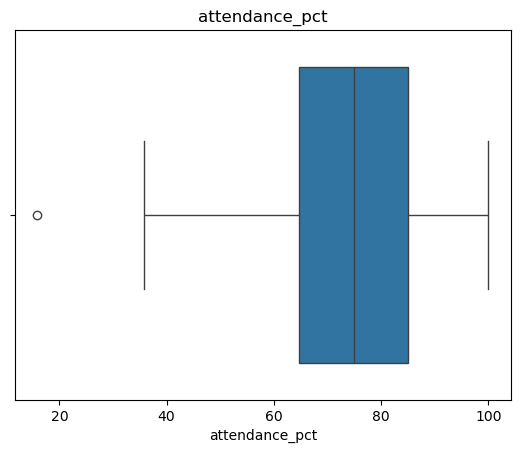

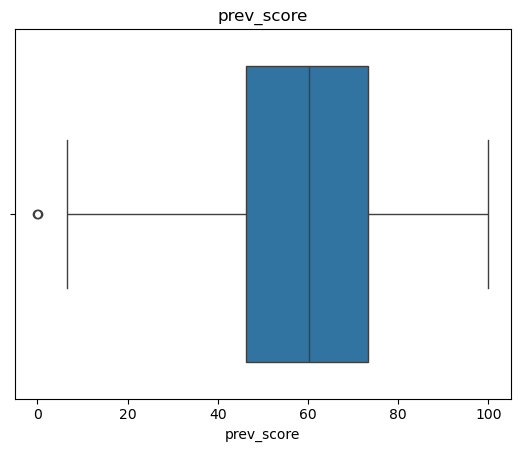

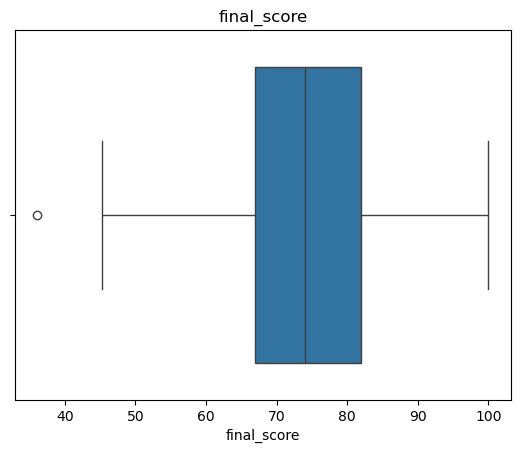

In [12]:
# Box Plot - Outliers detection through Box Plot
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['study_hours', 'attendance_pct', 'prev_score', 'final_score']:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [13]:
#IQR - Inter Quartile Range
for col in ['study_hours', 'attendance_pct', 'prev_score', 'final_score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col} → {len(outliers)} outliers")

study_hours → 4 outliers
attendance_pct → 1 outliers
prev_score → 2 outliers
final_score → 1 outliers


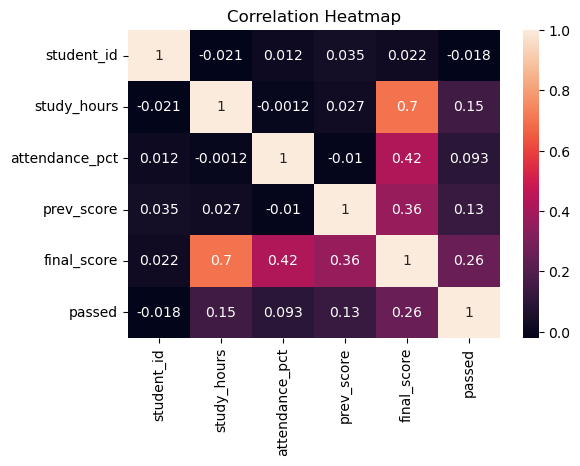

In [19]:
# Correlation 
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Remove student_id through 
X = df[['study_hours', 'attendance_pct', 'prev_score']]
y=df['final_score']
X.head()
y.head()

0    75.6
1    66.7
2    80.1
3    72.2
4    82.0
Name: final_score, dtype: float64

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((640, 3), (160, 3), (640,), (160,))

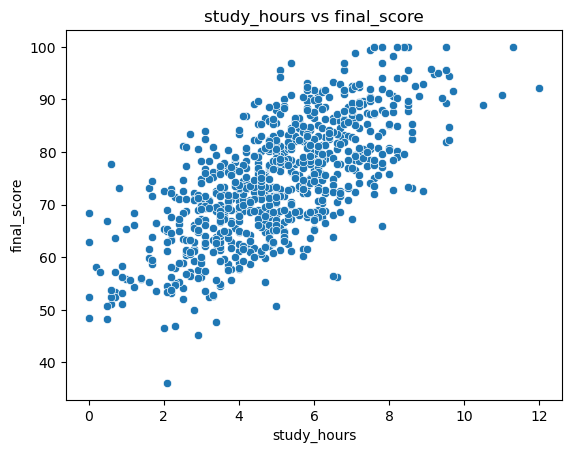

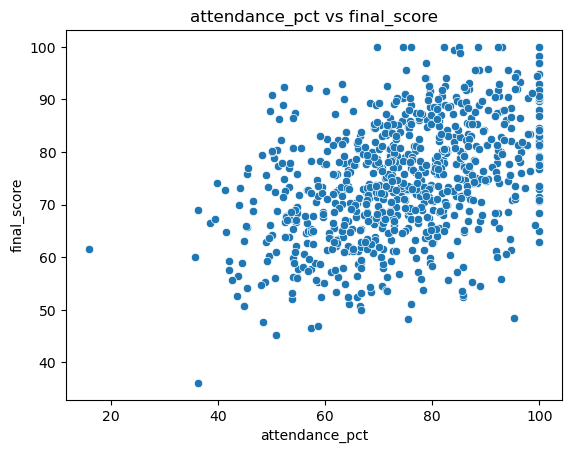

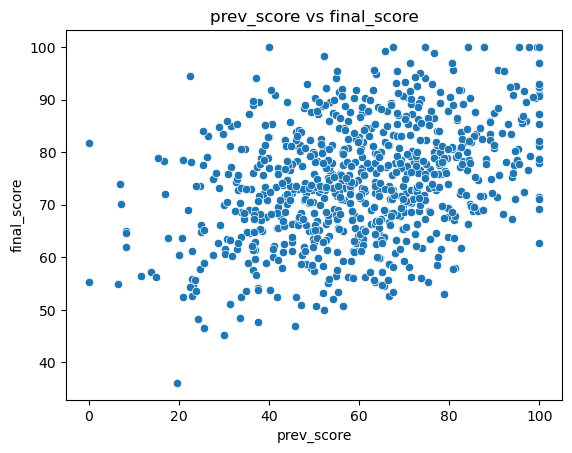

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['study_hours', 'attendance_pct', 'prev_score']

for col in features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df['final_score'])
    plt.title(f"{col} vs final_score")
    plt.xlabel(col)
    plt.ylabel("final_score")
    plt.show()

> So this shows we will not use Linear Regression 

In [18]:
# Model - Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(
    n_estimators=100,      
    random_state=42
)

# Step 7: Train model
model.fit(X_train, y_train)

# Step 8: Predictions
y_pred = model.predict(X_test)

# Step 9: Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.709799999999999
RMSE: 5.659250559923989
R2 Score: 0.731399701291027
